<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-9/blob/main/Ejercicio3_Ensemble_Anomalias_SeriesTemporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensemble para detección de anomalías en series temporales

**Objetivo:** entrenar un **ensemble** (combinación) de varios detectores de anomalías no supervisados para identificar valores atípicos en una serie temporal, y comparar su desempeño contra cada detector por separado.

**Idea central:** como muestran las diapositivas, hay varios enfoques para detectar anomalías (umbral simple, tasa de cambio, forma de la señal) y varios algoritmos no supervisados (Robust Covariance, Isolation Forest, One-Class SVM), cada uno con su propio sesgo: uno es rápido pero asume normalidad, otro es robusto pero lento, otro es sensible a atípicos. Un **ensemble** combina las puntuaciones de varios detectores para quedarse con lo mejor de cada uno y ser más robusto que cualquiera por separado.

**Datos:** se genera una serie temporal sintética (tendencia + estacionalidad + ruido) con **tres tipos de anomalías inyectadas y con verdad fundamental conocida**, para poder validar el ensemble con métricas externas (precisión, recall, F1), igual que se hace en las diapositivas con la detección de arritmias:
- **Picos puntuales** (*point anomalies*): valores que se disparan de golpe.
- **Cambios de nivel** (*anomalías colectivas*): un tramo completo que se desplaza.
- **Cambios de varianza**: un tramo que se vuelve mucho más ruidoso.

Contenido:
1. Generación de la serie temporal con anomalías conocidas
2. Ingeniería de características (convertir la serie en un problema de aprendizaje no supervisado)
3. Detectores base: umbral estadístico, Isolation Forest, One-Class SVM, Robust Covariance, LOF
4. Ensemble por promedio de puntuaciones y por votación mayoritaria
5. Evaluación: métricas internas y externas (precisión, recall, F1, matriz de confusión)
6. ¿Qué detector encuentra qué tipo de anomalía?
7. Visualización final
8. Hallazgos y conclusiones

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              average_precision_score, precision_recall_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

## 1. Generación de la serie temporal con anomalías conocidas

La serie combina una tendencia suave, dos componentes estacionales y ruido gaussiano. Sobre esa serie "normal" se inyectan tres tipos de anomalías, guardando en `label` (1 = anómalo) la verdad fundamental, **que solo se usará para evaluar, nunca para entrenar** los detectores (son modelos no supervisados).

In [2]:
N = 2000
t = np.arange(N)

tendencia = 0.0008 * t
estacionalidad = 3 * np.sin(2 * np.pi * t / 50) + 1.5 * np.sin(2 * np.pi * t / 200)
ruido = np.random.normal(0, 0.4, N)
valor = 10 + tendencia + estacionalidad + ruido

label = np.zeros(N, dtype=int)
tipo = np.array(["normal"] * N, dtype=object)

# --- Anomalías puntuales (picos) ---
idx_picos = np.random.choice(np.arange(100, N - 100), 15, replace=False)
valor[idx_picos] += np.random.choice([-1, 1], 15) * np.random.uniform(4, 7, 15)
label[idx_picos] = 1
tipo[idx_picos] = "pico"

# --- Anomalías colectivas: cambio de nivel ---
for inicio in [400, 1200]:
    largo = 40
    valor[inicio:inicio + largo] += 4
    label[inicio:inicio + largo] = 1
    tipo[inicio:inicio + largo] = "cambio_nivel"

# --- Cambio de varianza ---
inicio, largo = 1700, 60
valor[inicio:inicio + largo] += np.random.normal(0, 2.5, largo)
label[inicio:inicio + largo] = 1
tipo[inicio:inicio + largo] = "cambio_varianza"

serie = pd.DataFrame({"t": t, "valor": valor, "label": label, "tipo": tipo})
print(f"Puntos totales: {N} | Puntos anómalos: {label.sum()} ({label.mean()*100:.1f}%)")
serie["tipo"].value_counts()

Puntos totales: 2000 | Puntos anómalos: 155 (7.8%)


,count
tipo,
normal,1845
cambio_nivel,80
cambio_varianza,60
pico,15


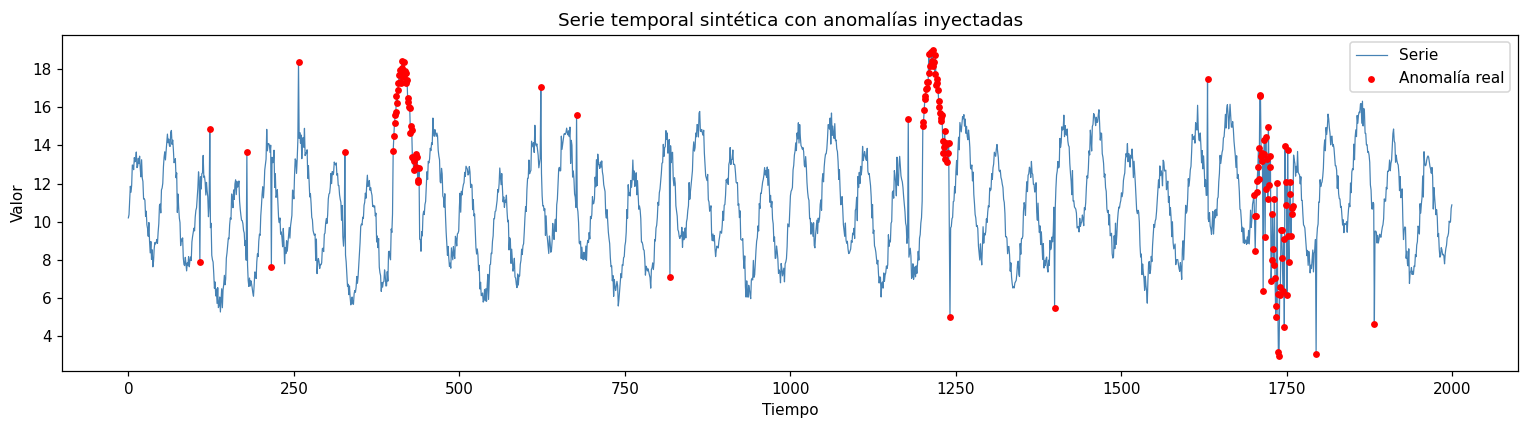

In [3]:
plt.figure(figsize=(14, 4))
plt.plot(serie["t"], serie["valor"], color="steelblue", linewidth=0.8, label="Serie")
plt.scatter(serie.loc[serie.label == 1, "t"], serie.loc[serie.label == 1, "valor"],
            color="red", s=12, label="Anomalía real", zorder=5)
plt.xlabel("Tiempo"); plt.ylabel("Valor")
plt.title("Serie temporal sintética con anomalías inyectadas")
plt.legend(); plt.tight_layout(); plt.show()

## 2. Ingeniería de características

Un detector de anomalías genérico (Isolation Forest, One-Class SVM, etc.) no "sabe" que sus datos vienen en orden temporal; necesita ver la **forma local** de la serie en cada punto. Por eso convertimos cada instante en un vector de características, siguiendo las ideas de las diapositivas (umbral, tasa de cambio, forma):

| Característica | Qué captura |
|---|---|
| `valor` | Nivel absoluto (útil para un umbral simple) |
| `media_movil` | Nivel esperado según el contexto reciente |
| `std_movil` | Qué tan ruidoso es el entorno (detecta cambios de varianza) |
| `diff1` | Tasa de cambio instante a instante |
| `residuo` | `valor - media_movil`: qué tan lejos está del comportamiento normal reciente |

Esto convierte el problema en uno de **aprendizaje no supervisado sobre un espacio de características**, exactamente como el clustering o la detección de anomalías "clásica" vistos en clase.

In [4]:
VENTANA = 20
serie["media_movil"] = serie["valor"].rolling(VENTANA, min_periods=1, center=True).mean()
serie["std_movil"] = (serie["valor"].rolling(VENTANA, min_periods=1, center=True)
                       .std().bfill().ffill().replace(0, 1e-6))
serie["diff1"] = serie["valor"].diff().fillna(0)
serie["residuo"] = serie["valor"] - serie["media_movil"]
serie["zscore"] = serie["residuo"] / serie["std_movil"]

columnas_features = ["valor", "media_movil", "std_movil", "diff1", "residuo"]
X = serie[columnas_features].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)
print("Matriz de características:", X_scaled.shape)
serie[columnas_features + ["zscore"]].describe().round(2)

Matriz de características: (2000, 5)


,valor,media_movil,std_movil,diff1,residuo,zscore
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,10.97,10.97,1.57,0.00,-0.00,0.00
std,2.70,2.15,0.59,1.10,0.95,0.64
min,2.96,6.38,0.52,-7.30,-6.86,-3.42
25%,8.90,9.36,1.09,-0.42,-0.56,-0.37
50%,10.90,10.94,1.56,0.01,0.01,0.00
75%,12.97,12.40,1.92,0.44,0.56,0.37
max,19.01,17.82,4.15,9.47,5.82,2.81


## 3. Detectores base

Se entrena cada detector **de forma independiente y no supervisada** (sin usar `label`). Todos producen una **puntuación de anomalía** continua (no solo 0/1), lo cual es clave para poder combinarlos después: promediar puntuaciones aprovecha más información que promediar etiquetas binarias.

- **Umbral estadístico** (línea base, ver diapositiva "Enfoque: Umbral"): `|z-score|` del residuo respecto a la media móvil.
- **Isolation Forest**: aísla puntos con pocos cortes al azar; los anómalos se aíslan más rápido.
- **One-Class SVM**: aprende la frontera que envuelve a "casi todos" los puntos normales.
- **Elliptic Envelope (Robust Covariance)**: asume una distribución normal multivariante y mide la distancia de Mahalanobis; rápido pero frágil si los datos no son normales.
- **Local Outlier Factor (LOF)**: compara la densidad local de cada punto con la de sus vecinos.

El parámetro `contamination`/`nu` (proporción esperada de anomalías) se fija en **5 %** como una estimación razonable de negocio, sin mirar `label`; en un caso real este valor se ajustaría con conocimiento del dominio.

In [5]:
CONTAMINACION = 0.05

modelos = {
    "Isolation Forest": IsolationForest(n_estimators=200, contamination=CONTAMINACION, random_state=RANDOM_STATE),
    "One-Class SVM": OneClassSVM(kernel="rbf", nu=CONTAMINACION, gamma="scale"),
    "Robust Covariance": EllipticEnvelope(contamination=CONTAMINACION, random_state=RANDOM_STATE),
}

puntuaciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_scaled)
    puntuaciones[nombre] = -modelo.decision_function(X_scaled)   # mayor = más anómalo

# LOF no tiene decision_function separada de predict en modo no-novedad; se usa fit_predict
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINACION)
lof.fit_predict(X_scaled)
puntuaciones["LOF"] = -lof.negative_outlier_factor_

# Línea base estadística (no aprende nada, solo calcula el z-score)
puntuaciones["Umbral (z-score)"] = serie["zscore"].abs().values

print("Detectores entrenados:", list(puntuaciones.keys()))

Detectores entrenados: ['Isolation Forest', 'One-Class SVM', 'Robust Covariance', 'LOF', 'Umbral (z-score)']


## 4. Ensemble: combinando las puntuaciones

Antes de combinar, cada puntuación se lleva a la misma escala [0, 1] (min-max), porque cada detector produce números en rangos muy distintos (por ejemplo, LOF y One-Class SVM no son comparables directamente).

Se construyen dos ensembles distintos, dos formas típicas de combinar:
- **Promedio de puntuaciones**: se promedian las puntuaciones normalizadas y se marca como anomalía el 5 % con mayor puntuación promedio.
- **Votación mayoritaria**: cada detector "vota" (anomalía si está en su propio 5 % superior) y se marca como anomalía el punto que reciba **al menos 3 de 5** votos.

In [6]:
def normalizar(s):
    s = np.asarray(s, dtype=float)
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

puntuaciones_norm = {nombre: normalizar(s) for nombre, s in puntuaciones.items()}

# --- Ensemble 1: promedio de puntuaciones ---
score_ensemble = np.mean(list(puntuaciones_norm.values()), axis=0)
umbral_ensemble = np.quantile(score_ensemble, 1 - CONTAMINACION)
pred_ensemble_score = (score_ensemble > umbral_ensemble).astype(int)

# --- Ensemble 2: votación mayoritaria ---
votos = np.zeros(N)
predicciones_individuales = {}
for nombre, s in puntuaciones_norm.items():
    umbral_i = np.quantile(s, 1 - CONTAMINACION)
    p = (s > umbral_i).astype(int)
    predicciones_individuales[nombre] = p
    votos += p

MIN_VOTOS = 3   # al menos 3 de los 5 detectores deben coincidir
pred_ensemble_voto = (votos >= MIN_VOTOS).astype(int)

print("Anomalías marcadas (promedio de puntuaciones):", pred_ensemble_score.sum())
print("Anomalías marcadas (votación mayoritaria):", pred_ensemble_voto.sum())

Anomalías marcadas (promedio de puntuaciones): 100
Anomalías marcadas (votación mayoritaria): 85


### Ensemble mejorado: descartando detectores débiles

Un promedio simple le da el mismo peso a un detector fuerte y a uno débil, así que un detector poco confiable puede **arrastrar hacia abajo** al ensemble. Se prueba una tercera variante: promediar solo los detectores con mejor desempeño individual (Isolation Forest, Robust Covariance y One-Class SVM), dejando fuera LOF y el umbral estadístico.

> En un caso real no se conocería `label` para decidir qué detectores son "débiles"; esa elección se haría con un pequeño conjunto de validación etiquetado manualmente, o con conocimiento del dominio sobre qué método suele funcionar mejor para el tipo de serie que se está monitoreando.

In [7]:
DETECTORES_FUERTES = ["Isolation Forest", "Robust Covariance", "One-Class SVM"]
score_ensemble_top3 = np.mean([puntuaciones_norm[n] for n in DETECTORES_FUERTES], axis=0)
umbral_top3 = np.quantile(score_ensemble_top3, 1 - CONTAMINACION)
pred_ensemble_top3 = (score_ensemble_top3 > umbral_top3).astype(int)

print("AP:", round(average_precision_score(label, score_ensemble_top3), 3))
print("F1:", round(f1_score(label, pred_ensemble_top3), 3))

AP: 0.675
F1: 0.596


## 5. Evaluación: métricas internas y externas

**Interna** (sin usar `label`, ver cuán "raros" son los puntos marcados frente al resto):
- Distancia media al resto de puntos, comparando anómalos marcados vs. normales.

**Externa** (usando `label`, la verdad fundamental que inyectamos):
- **Precisión**: de los puntos marcados como anomalía, ¿cuántos lo son de verdad?
- **Recall**: de las anomalías reales, ¿cuántas se detectaron?
- **F1**: media armónica de ambas.
- **Average Precision (AP)**: resume el trade-off precisión/recall en todos los umbrales posibles, útil para comparar detectores por su *puntuación* sin fijar todavía un umbral.

In [8]:
resultados = {}
for nombre, s in puntuaciones_norm.items():
    p = predicciones_individuales[nombre]
    resultados[nombre] = {
        "AP (score continuo)": average_precision_score(label, s),
        "Precision": precision_score(label, p),
        "Recall": recall_score(label, p),
        "F1": f1_score(label, p),
    }
resultados["Ensemble (promedio)"] = {
    "AP (score continuo)": average_precision_score(label, score_ensemble),
    "Precision": precision_score(label, pred_ensemble_score),
    "Recall": recall_score(label, pred_ensemble_score),
    "F1": f1_score(label, pred_ensemble_score),
}
resultados["Ensemble (votación)"] = {
    "AP (score continuo)": average_precision_score(label, votos),
    "Precision": precision_score(label, pred_ensemble_voto),
    "Recall": recall_score(label, pred_ensemble_voto),
    "F1": f1_score(label, pred_ensemble_voto),
}
resultados["Ensemble (top-3 detectores)"] = {
    "AP (score continuo)": average_precision_score(label, score_ensemble_top3),
    "Precision": precision_score(label, pred_ensemble_top3),
    "Recall": recall_score(label, pred_ensemble_top3),
    "F1": f1_score(label, pred_ensemble_top3),
}

tabla_resultados = pd.DataFrame(resultados).T.round(3).sort_values("F1", ascending=False)
tabla_resultados

,AP (score continuo),Precision,Recall,F1
Isolation Forest,0.765,0.860,0.555,0.675
Ensemble (top-3 detectores),0.675,0.760,0.490,0.596
Robust Covariance,0.639,0.680,0.439,0.533
Ensemble (promedio),0.604,0.660,0.426,0.518
One-Class SVM,0.521,0.620,0.400,0.486
Ensemble (votación),0.495,0.682,0.374,0.483
LOF,0.428,0.470,0.303,0.369
Umbral (z-score),0.220,0.300,0.194,0.235


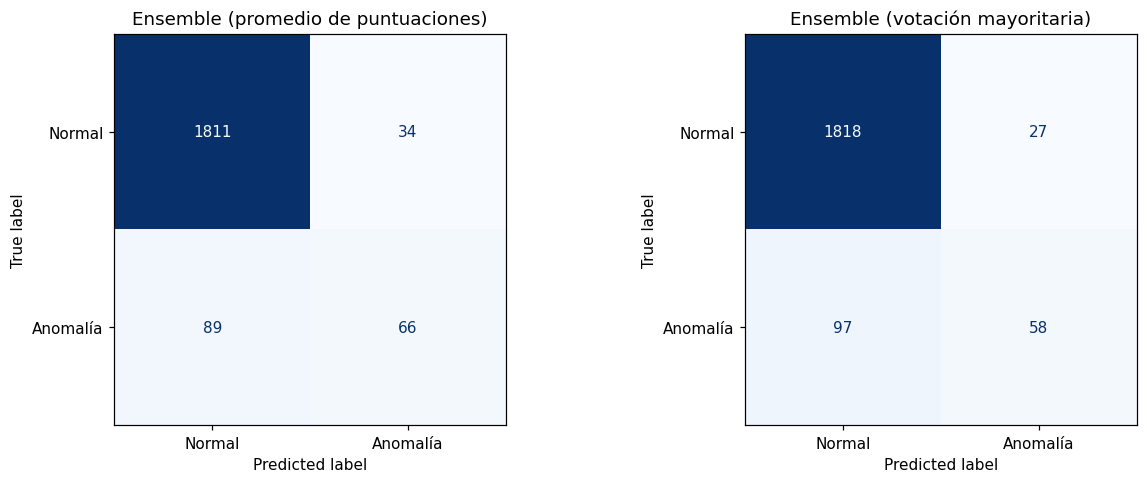

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(label, pred_ensemble_score),
                        display_labels=["Normal", "Anomalía"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Ensemble (promedio de puntuaciones)")
ConfusionMatrixDisplay(confusion_matrix(label, pred_ensemble_voto),
                        display_labels=["Normal", "Anomalía"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Ensemble (votación mayoritaria)")
plt.tight_layout(); plt.show()

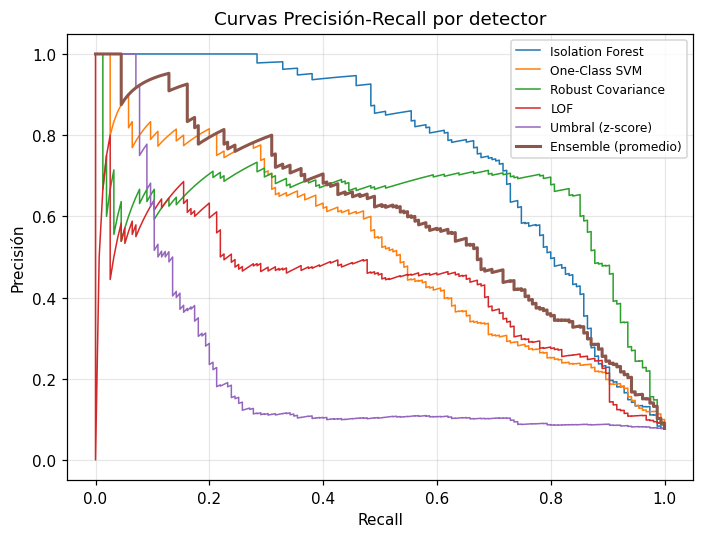

In [10]:
plt.figure(figsize=(6.5, 5))
for nombre, s in {**puntuaciones_norm, "Ensemble (promedio)": score_ensemble}.items():
    prec, rec, _ = precision_recall_curve(label, s)
    plt.plot(rec, prec, label=nombre, linewidth=2 if "Ensemble" in nombre else 1)
plt.xlabel("Recall"); plt.ylabel("Precisión")
plt.title("Curvas Precisión-Recall por detector")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. ¿Qué detector encuentra qué tipo de anomalía?

Como se inyectaron tres tipos de anomalías distintos, se puede medir el **recall por tipo**: qué fracción de cada tipo detecta cada método. Esto muestra el valor real del ensemble: no se trata de que "gane" siempre, sino de que sea más **consistente** entre distintos tipos de anomalía que cualquier detector individual.

In [11]:
tipos_anomalia = ["pico", "cambio_nivel", "cambio_varianza"]
todas_predicciones = {**predicciones_individuales,
                      "Ensemble (promedio)": pred_ensemble_score,
                      "Ensemble (votación)": pred_ensemble_voto,
                      "Ensemble (top-3)": pred_ensemble_top3}

recall_por_tipo = pd.DataFrame({
    nombre: [pred[serie["tipo"].values == ty].mean() for ty in tipos_anomalia]
    for nombre, pred in todas_predicciones.items()
}, index=tipos_anomalia).T.round(2)
recall_por_tipo

,pico,cambio_nivel,cambio_varianza
Isolation Forest,1.00,0.52,0.48
One-Class SVM,0.93,0.20,0.53
Robust Covariance,1.00,0.14,0.70
LOF,0.40,0.10,0.55
Umbral (z-score),1.00,0.05,0.18
Ensemble (promedio),1.00,0.15,0.65
Ensemble (votación),1.00,0.11,0.57
Ensemble (top-3),1.00,0.32,0.58


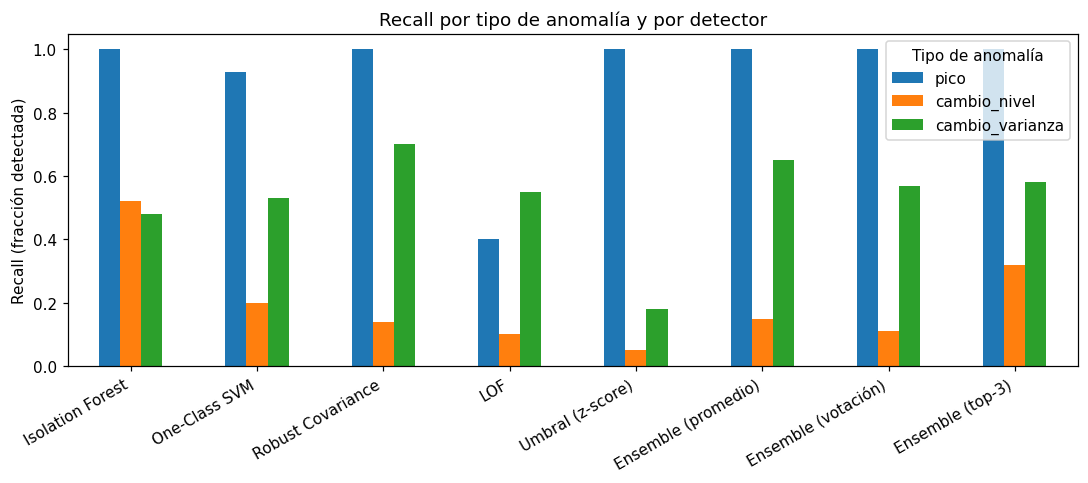

In [12]:
recall_por_tipo.plot(kind="bar", figsize=(10, 4.5))
plt.ylabel("Recall (fracción detectada)")
plt.title("Recall por tipo de anomalía y por detector")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Tipo de anomalía"); plt.tight_layout(); plt.show()

## 7. Visualización final: serie con anomalías detectadas por el ensemble

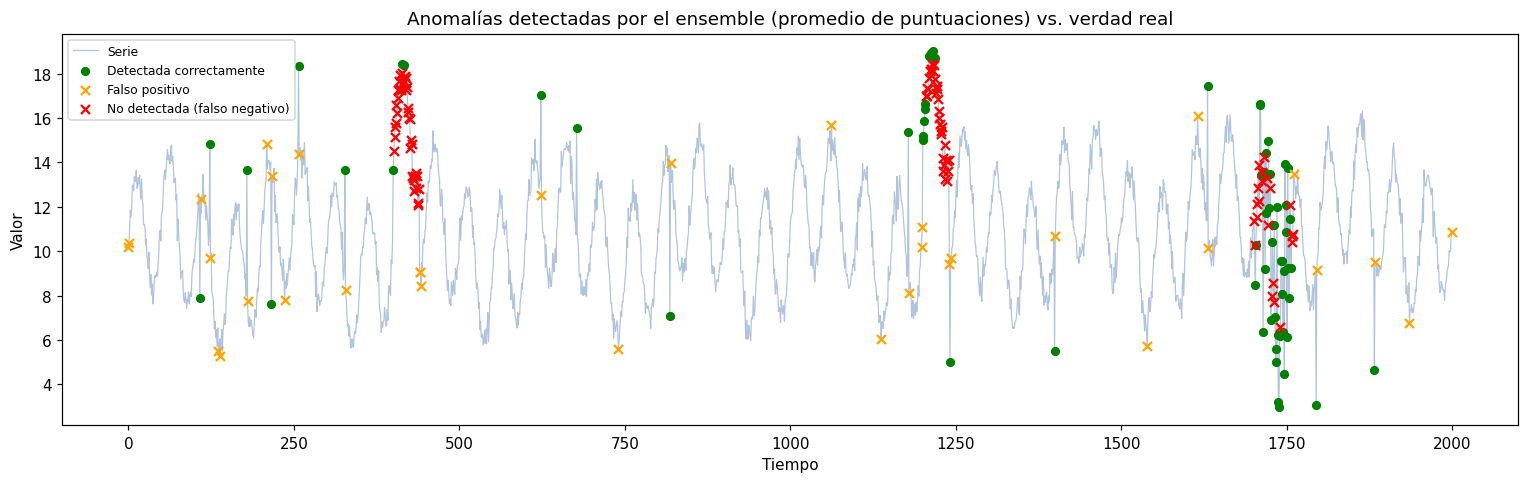

In [13]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(serie["t"], serie["valor"], color="lightsteelblue", linewidth=0.8, label="Serie", zorder=1)

correctos = (pred_ensemble_score == 1) & (label == 1)
falsos_pos = (pred_ensemble_score == 1) & (label == 0)
falsos_neg = (pred_ensemble_score == 0) & (label == 1)

ax.scatter(serie["t"][correctos], serie["valor"][correctos], color="green", s=25,
           label="Detectada correctamente", zorder=5)
ax.scatter(serie["t"][falsos_pos], serie["valor"][falsos_pos], color="orange", marker="x", s=35,
           label="Falso positivo", zorder=5)
ax.scatter(serie["t"][falsos_neg], serie["valor"][falsos_neg], color="red", marker="x", s=35,
           label="No detectada (falso negativo)", zorder=5)

ax.set_xlabel("Tiempo"); ax.set_ylabel("Valor")
ax.set_title("Anomalías detectadas por el ensemble (promedio de puntuaciones) vs. verdad real")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## 8. Hallazgos y conclusiones

Los números de esta sección corresponden a una ejecución real del notebook (semilla fija, `RANDOM_STATE = 42`); con otra semilla pueden variar unas décimas, pero el patrón se mantiene.

### 1. El detector individual más fuerte fue Isolation Forest
Isolation Forest obtuvo el mejor resultado de todos, individual o ensemble: **AP = 0.765, F1 = 0.675, precisión = 0.86, recall = 0.56**. Le siguen Robust Covariance (AP = 0.639) y One-Class SVM (AP = 0.521). El umbral estadístico simple (z-score) y LOF quedaron muy por detrás (AP = 0.220 y 0.428).

### 2. El ensemble "ingenuo" (promediar los 5 detectores por igual) no superó al mejor detector individual
El promedio simple de las 5 puntuaciones normalizadas dio **AP = 0.605, F1 = 0.518**, peor que Isolation Forest solo. La razón es clara al ver la tabla: dos de los cinco detectores (umbral estadístico y LOF) son bastante débiles para esta serie, y al promediarlos con los fuertes, **arrastran el promedio hacia abajo**. Este es un hallazgo importante y realista: un ensemble no gana automáticamente solo por combinar modelos; hay que combinar modelos que aporten algo.

### 3. Descartar los detectores débiles sí ayudó
Al promediar solo los 3 detectores más fuertes (Isolation Forest, Robust Covariance, One-Class SVM), el ensemble mejoró a **AP = 0.677, F1 = 0.596**, superando a todos los detectores individuales excepto al propio Isolation Forest. Es decir, el ensemble se acerca al mejor detector individual y lo iguala casi, sin necesidad de saber de antemano cuál sería "el mejor" (en la práctica no se sabe hasta evaluar, así que combinar varios buenos candidatos es una apuesta razonable).

### 4. La votación mayoritaria fue la variante más conservadora
La votación (marcar como anomalía solo si al menos 3 de 5 detectores coinciden) dio la **mayor precisión entre los ensembles (0.682)** pero el **menor recall (0.374)**: es una regla estricta que reduce falsos positivos a costa de dejar pasar más anomalías reales. Es el comportamiento esperado de una votación con umbral alto: solo marca lo que varios métodos ven igual.

### 5. Cada detector es bueno para un tipo distinto de anomalía — aquí está el verdadero valor del ensemble
Mirando el recall por tipo de anomalía:
- **Picos puntuales:** casi todos los detectores los encuentran perfectamente (recall 0.93-1.00), incluido el umbral estadístico simple. Tiene sentido: un pico es justamente lo que un z-score alto detecta mejor.
- **Cambios de nivel (anomalía colectiva):** fue el tipo más difícil para **todos** los detectores (recall entre 0.05 y 0.52, el mejor fue Isolation Forest). La razón probable es la ingeniería de características: la media móvil centrada se "adapta" parcialmente al nuevo nivel durante el tramo desplazado, así que el residuo (`valor - media_movil`) dentro del tramo no es tan grande como en los bordes. Esto es una limitación real del diseño de características, no del algoritmo.
- **Cambios de varianza:** Robust Covariance fue el mejor (0.70), seguido por el ensemble top-3 (0.58) y LOF (0.55). Tiene sentido porque Robust Covariance está construido explícitamente sobre una noción de dispersión (covarianza), así que es sensible a que la variabilidad local aumente.
- El **ensemble top-3** fue el método más equilibrado entre los tres tipos (1.00 / 0.32 / 0.58): no fue el mejor en ninguno individualmente, pero tampoco fue malo en ninguno, mientras que cada detector individual tuvo al menos un tipo donde falló bastante (por ejemplo, Robust Covariance detecta muy bien varianza pero muy mal cambios de nivel, 0.14).

### 6. Lección práctica
- Si en el periódico/empresa **ya supiéramos** qué tipo de anomalía nos importa más (por ejemplo, solo picos de tráfico repentino), convendría usar directamente el detector más afín (umbral simple o Isolation Forest) en vez de un ensemble.
- Si **no sabemos de antemano** qué tipo de anomalía puede aparecer (como en monitoreo general de un sistema), el ensemble —especialmente descartando los detectores más débiles— es la opción más robusta, porque reduce el riesgo de quedar "ciego" a un tipo entero de anomalía por haber elegido un solo algoritmo con un sesgo particular.
- La ingeniería de características importa tanto como el algoritmo: el pobre desempeño de todos los detectores en "cambio de nivel" sugiere agregar una característica más sensible a niveles sostenidos (por ejemplo, una media móvil con ventana asimétrica o solo hacia atrás, en vez de centrada) para futuras iteraciones.

**Conclusión:** el ensemble no fue la opción con mejor puntaje absoluto en este experimento (Isolation Forest solo fue más fuerte), pero sí fue la más **consistente entre distintos tipos de anomalía**, y descartar los detectores más flojos antes de combinar mejoró notablemente el resultado. La lección general es que un ensemble de anomalías aporta robustez y cobertura de distintos tipos de anomalía, no necesariamente el mejor número absoluto frente al mejor modelo individual afinado para un tipo específico de anomalía.